# Pytorch with Autograd

### What is Autograd?

**Autograd** is PyTorch’s automatic differentiation engine. It automatically calculates **gradients**.

Instead of manually computing the gradients using calculus, PyTorch records the operations in a **computational graph**. When `.backward()` is called on the loss, it uses the chain rule to compute the gradients of each parameter.

In [2]:
import torch

x = torch.tensor(2.0, requires_grad=True)
y = x ** 2 + 3 * x + 5 

y.backward()

print(x.grad)

tensor(7.)


Another example: We know that if $z = x^T y$, then $\frac{\partial z}{\partial x} = y$ and $\frac{\partial z}{\partial y} = x$. The example below demonstrates that.

In [3]:
x = torch.tensor([2.0, 3.0, 4.0], requires_grad=True)
y = torch.tensor([-1.0, 1.0, -3.0], requires_grad=True)
z = x @ y

print(f"z is {z}")

z.backward()

print(f"gradient of z with respect to x is {x.grad}")
print(f"gradient of z with respect to y is {y.grad}")

z is -11.0
gradient of z with respect to x is tensor([-1.,  1., -3.])
gradient of z with respect to y is tensor([2., 3., 4.])


There can be several layers of computation before taking the gradient.

In [4]:
x = torch.tensor([3.5], requires_grad=True)
y = 2 + x
z = 2 * y ** 2
t = z * x ** 2

t.backward()
print(x.grad)

tensor([693.])


**Note**: You can use statements within `with torch.no_grad():` to prevent pytorch from tracking the computational history, for example in evaluation.

# MNIST dataset and torchvision

The **MNIST dataset** contains 70,000 images of handwritten digits (0–9), each of size 28×28 pixels. It's one of the most common datasets for image classification because of its simple structure and small size.

`torchvision` is a library that can be used to download famous datasets, pre-trained models, and image transformations for pytorch.

In [6]:
import torchvision

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True)

print(train_dataset)
print(test_dataset)

100%|██████████| 9.91M/9.91M [00:29<00:00, 333kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 147kB/s]
100%|██████████| 1.65M/1.65M [00:13<00:00, 121kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 265kB/s]

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test


You can use `torchvision.transforms` to change images in any way you want.

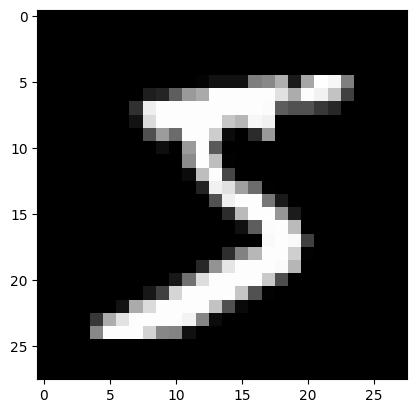

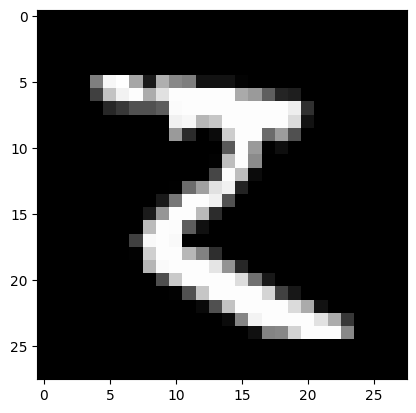

In [7]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]
plt.imshow(image, cmap='gray')
plt.show()

transform = torchvision.transforms.RandomHorizontalFlip(p=1)
plt.imshow(transform(image), cmap='gray')
plt.show()

You can also apply transforms when getting the dataset.

In [8]:
transform = torchvision.transforms.Compose([torchvision.transforms.RandomRotation(degrees=45), torchvision.transforms.RandomInvert()])

train_dataset_transformed = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset_transformed = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

You can view some images of the MNIST dataset and their transformed version below.

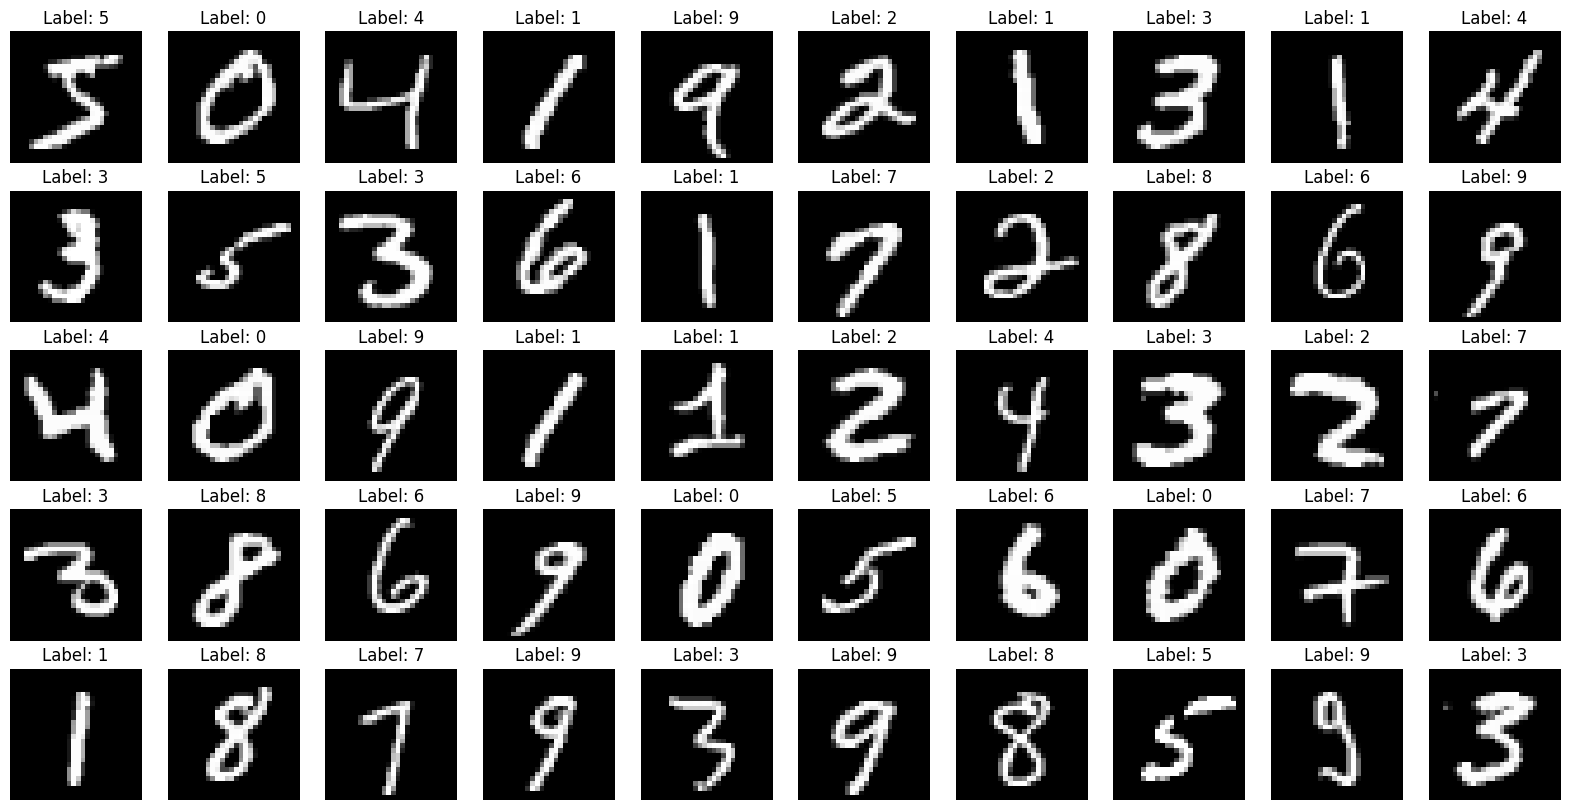

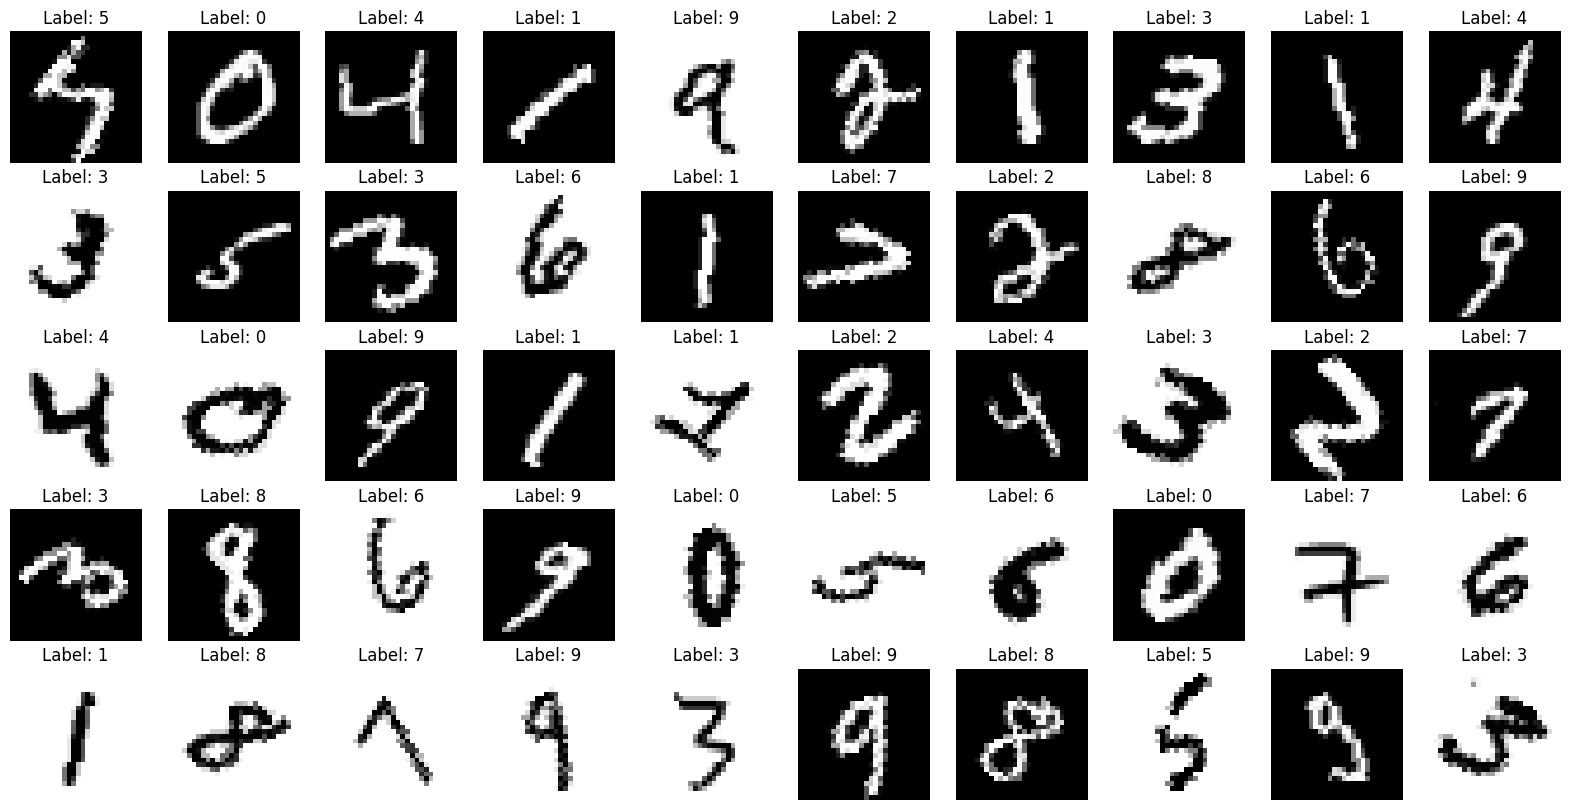

In [9]:
def show_first_50(dataset):
    fig, axes = plt.subplots(5, 10, figsize=(20, 10))
    for i in range(50):
        image, label = dataset[i]
        axes[i // 10][i % 10].imshow(image, cmap='gray')
        axes[i // 10][i % 10].set_title(f"Label: {label}")
        axes[i // 10][i % 10].axis('off')
    plt.show()

show_first_50(train_dataset)
show_first_50(train_dataset_transformed)

# Project

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Loading dataset

In [11]:
transform = transforms.ToTensor()  # Converts images to PyTorch tensors

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000)

torch.Size([1, 28, 28]) 7
torch.Size([28, 28])


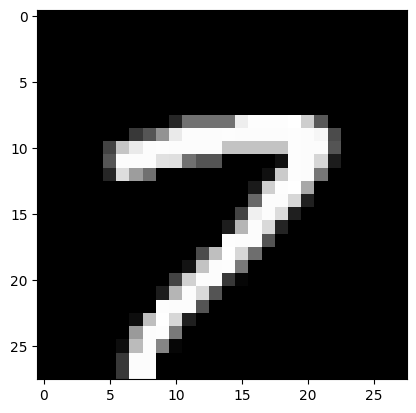

In [12]:
image, label = train_dataset[123]
print(image.shape, label)
print(image.squeeze().shape)
plt.imshow(image.squeeze(), cmap='gray')

## Model Definition

Below is a basic MLP with:
- Input layer: 784 neurons (28×28 pixels)
- Hidden layer: 128 neurons with ReLU activation
- Output layer: 10 neurons (one for each digit class)

We define weights and biases manually as `nn.Parameter`, which makes them trainable and automatically tracked by Autograd.


In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.w1 = nn.Parameter(torch.randn(784, 128) * 0.01)
        self.b1 = nn.Parameter(torch.zeros(128))
        self.w2 = nn.Parameter(torch.randn(128, 10) * 0.01)
        self.b2 = nn.Parameter(torch.zeros(10))

    def forward(self, x):
        x = x.view(-1, 784)
        z1 = x @ self.w1 + self.b1
        a1 = F.relu(z1) 
        z2 = a1 @ self.w2 + self.b2
        return z2

In [14]:
def compute_loss(pred, target):
    return F.cross_entropy(pred, target)

def compute_accuracy(pred, target):
    return (pred.argmax(dim=1) == target).float().mean().item()

## Training

We use **Stochastic Gradient Descent (SGD)** to update model parameters based on the gradients from Autograd. In general, you can use any type of update algorithm by defining an optimizer (there are pre-defined optimizer in `torch.optim`)

Each epoch loops through all the training data once.

- `.zero_grad()` clears previous gradients
- `.backward()` computes gradients
- `.step()` updates parameters


In [ ]:
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
epochs = 5

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        preds = model(images)
        loss = compute_loss(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 1, Loss: 0.4044
Epoch 2, Loss: 0.4034
Epoch 3, Loss: 0.0040
Epoch 4, Loss: 0.4922
Epoch 5, Loss: 0.0953


Training on CPU can be slow. If you have GPU available (for example in google colab/kaggle), you can train by using GPU.

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [25]:
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 10

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images)
        loss = compute_loss(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.2327
Epoch 2, Loss: 0.1022
Epoch 3, Loss: 0.2021
Epoch 4, Loss: 0.0013
Epoch 5, Loss: 0.0293
Epoch 6, Loss: 0.0155
Epoch 7, Loss: 0.1169
Epoch 8, Loss: 0.0303
Epoch 9, Loss: 0.0835
Epoch 10, Loss: 0.0990


## Evaluation

In [29]:
model.eval()
test_loss = 0
test_acc = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images)
        test_loss += compute_loss(preds, labels).item()
        test_acc += compute_accuracy(preds, labels)

test_loss /= len(test_loader)
test_acc /= len(test_loader)

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


Test Loss: 0.1949, Test Accuracy: 0.9660


### Visualization

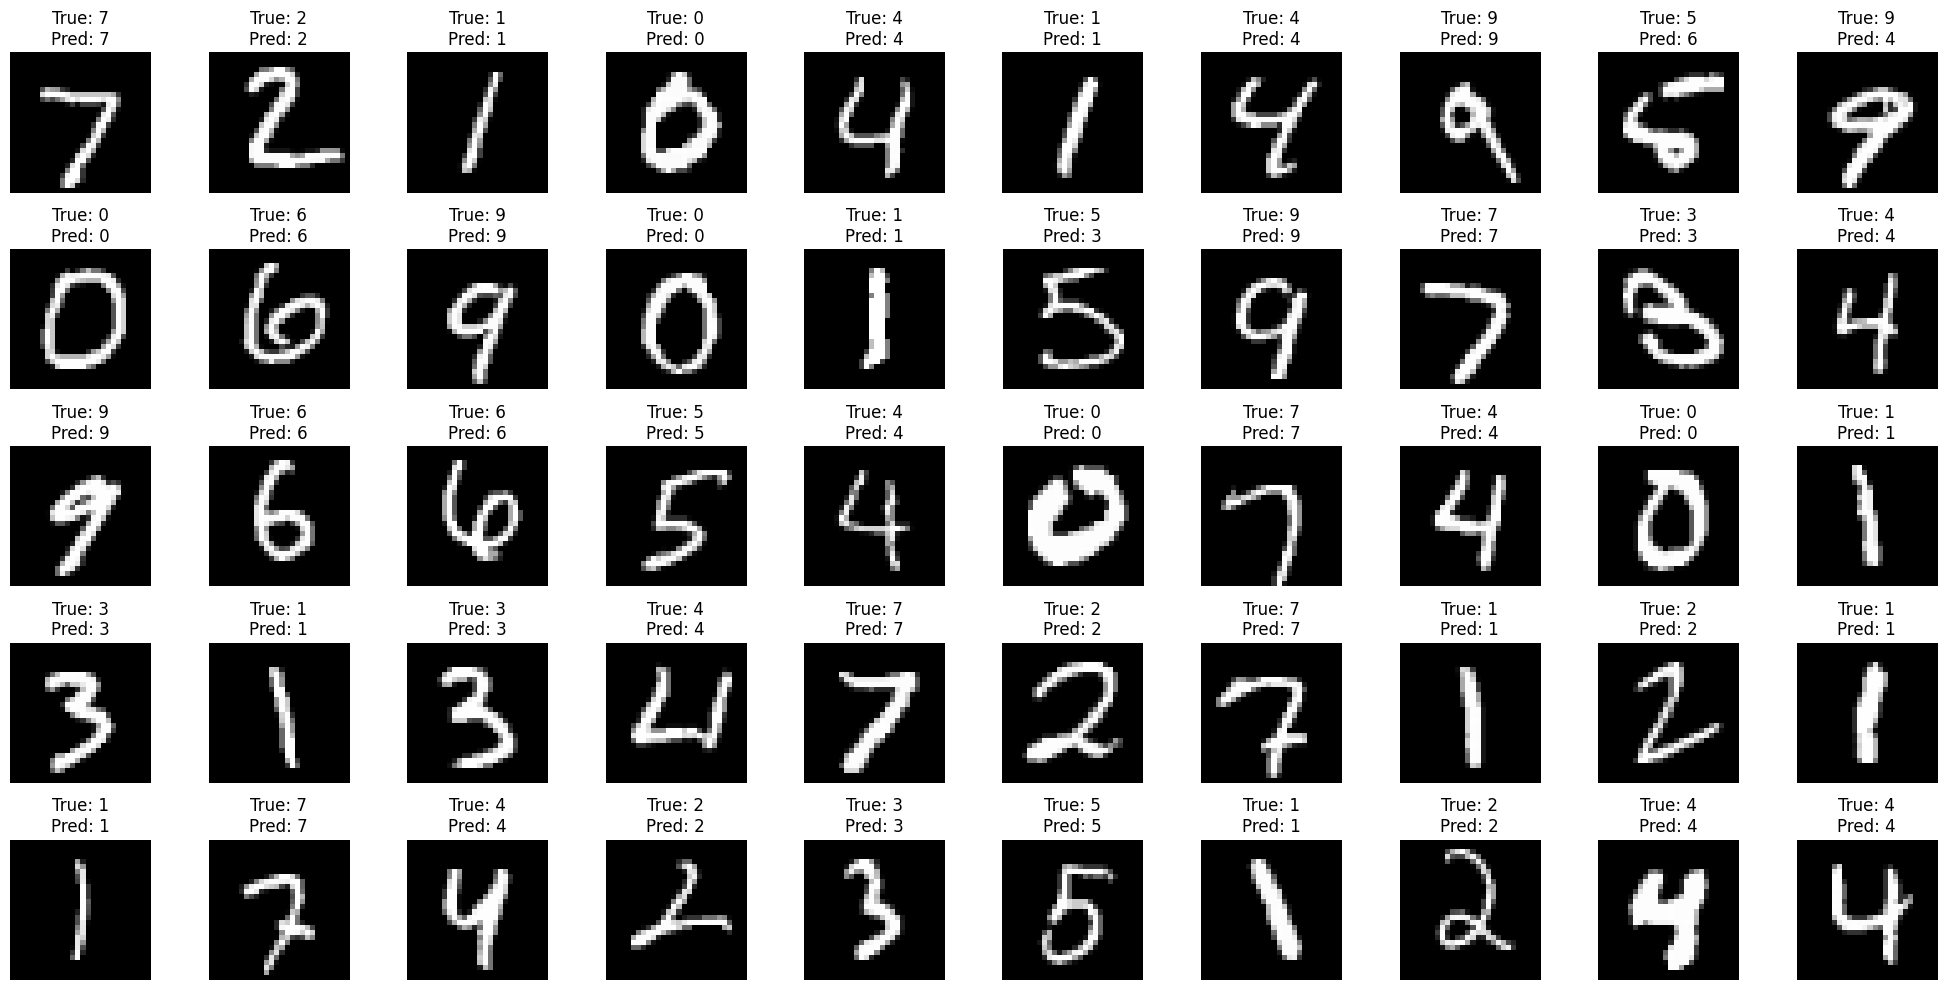

In [30]:
images, labels = next(iter(test_loader))
model.to('cpu')
preds = model(images)
pred_classes = preds.argmax(dim=1)

plt.figure(figsize=(20, 10))
for i in range(50):
    plt.subplot(5, 10, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"True: {labels[i]}\nPred: {pred_classes[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


Found 41 misclassified samples in this batch.


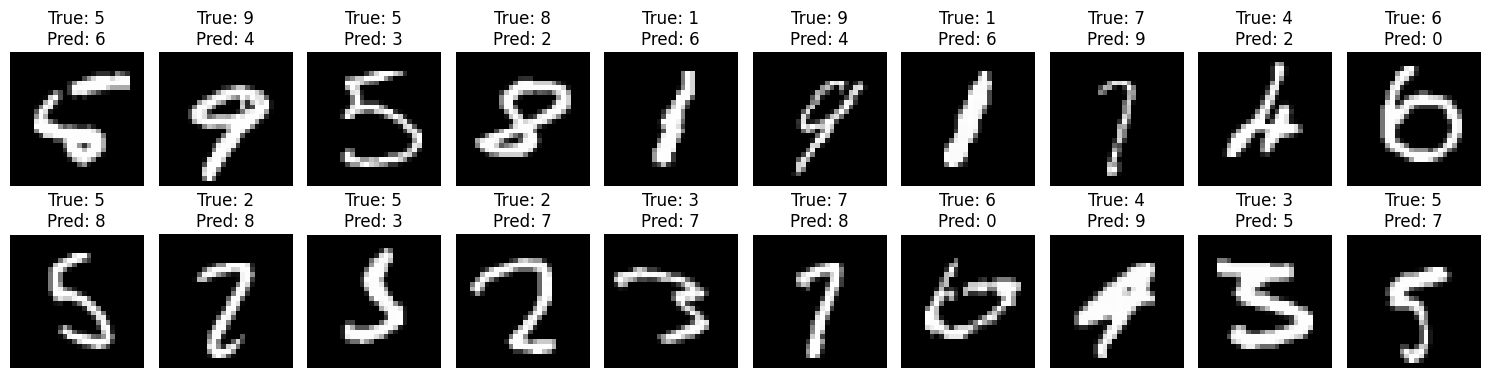

In [31]:
wrong_indices = (pred_classes != labels).nonzero(as_tuple=True)[0]
print(f"Found {len(wrong_indices)} misclassified samples in this batch.")

num_to_show = min(20, len(wrong_indices))
plt.figure(figsize=(15, 4))
for i in range(num_to_show):
    idx = wrong_indices[i]
    plt.subplot(2, 10, i+1)
    plt.imshow(images[idx].squeeze(), cmap='gray')
    plt.title(f"True: {labels[idx].item()}\nPred: {pred_classes[idx].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()